In [50]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import coherent, displace, basis


In [51]:
N = 30              # Hilbert space dimension
alpha = 0.7         # Coherent state amplitude

# Photon numbers
n_values = np.arange(N)

psi_plus = coherent(N, alpha)
psi_minus = coherent(N, -alpha)

D = displace(N, -alpha) #Displacement operator

psi_plus_displaced = D * psi_plus
psi_minus_displaced = D * psi_minus

In [52]:
P_plus = np.zeros(N)
P_minus = np.zeros(N)

P_plus = np.abs(
    psi_plus_displaced.full().flatten()
)**2

P_minus = np.abs(
    psi_minus_displaced.full().flatten()
)**2

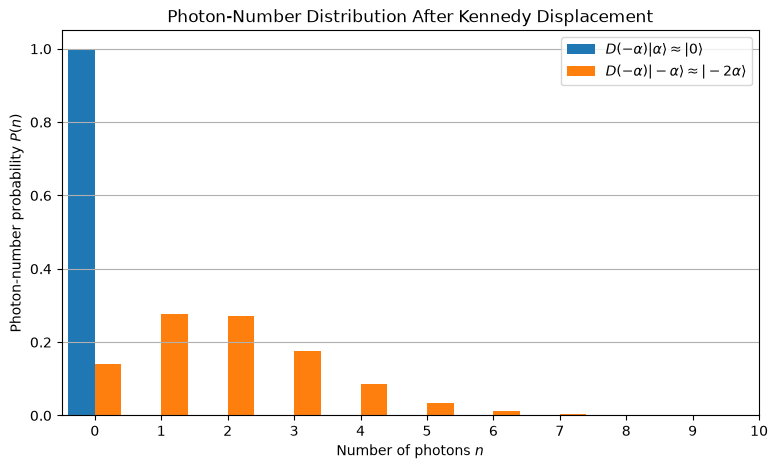

In [53]:
plt.figure(figsize=(9, 5))

plt.bar(n_values - 0.2, P_plus, width=0.4, label=r"$D(-\alpha)|\alpha\rangle \approx |0\rangle$")
plt.bar(n_values + 0.2, P_minus, width=0.4, label=r"$D(-\alpha)|-\alpha\rangle \approx |-2\alpha\rangle$")

plt.xlabel(r"Number of photons $n$")
plt.ylabel(r"Photon-number probability $P(n)$")

plt.title("Photon-Number Distribution After Kennedy Displacement")

plt.xticks(n_values)
plt.xlim(-0.5, 10)

plt.legend()
plt.grid(axis="y")

# Conditional Error Probabilities

In [54]:
# |+α> was sent, but we detect n >= 1
P_error_given_plus = np.sum(P_plus[1:])

# |-α> was sent, but we detect n = 0
P_error_given_minus = P_minus[0]

In [55]:
P_error_kennedy = 0.5 * (P_error_given_plus + P_error_given_minus)

print( "P(error | +α) =", P_error_given_plus)
print( "P(error | -α) =", P_error_given_minus)
print("Total Kennedy error probability =", P_error_kennedy)

P(error | +α) = 6.929026137922491e-33
P(error | -α) = 0.14085842092104495
Total Kennedy error probability = 0.07042921046052247


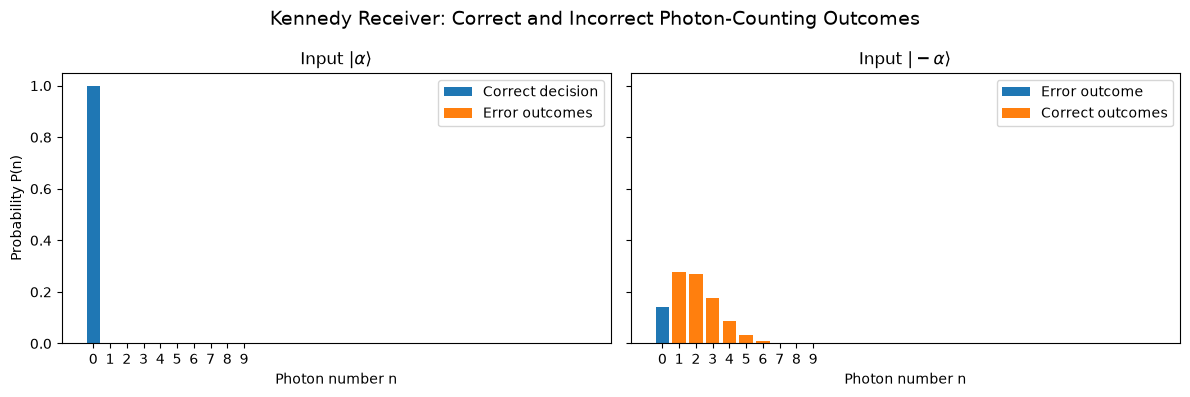

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# |+α> input

axes[0].bar(n_values[0], P_plus[0], label="Correct decision")

axes[0].bar(n_values[1:], P_plus[1:], label="Error outcomes")
axes[0].set_xlabel("Photon number n")
axes[0].set_ylabel("Probability P(n)")
axes[0].set_title( r"Input $|\alpha\rangle$")
axes[0].set_xticks(np.arange(0, 10))
axes[0].legend()

# |-alpha> input

axes[1].bar(n_values[0], P_minus[0], label="Error outcome")
axes[1].bar( n_values[1:], P_minus[1:], label="Correct outcomes")
axes[1].set_xlabel("Photon number n")
axes[1].set_title(r"Input $|-\alpha\rangle$")
axes[1].set_xticks(np.arange(0, 10))
axes[1].legend()

plt.suptitle("Kennedy Receiver: Correct and Incorrect Photon-Counting Outcomes", fontsize=14)
plt.tight_layout()
plt.show()

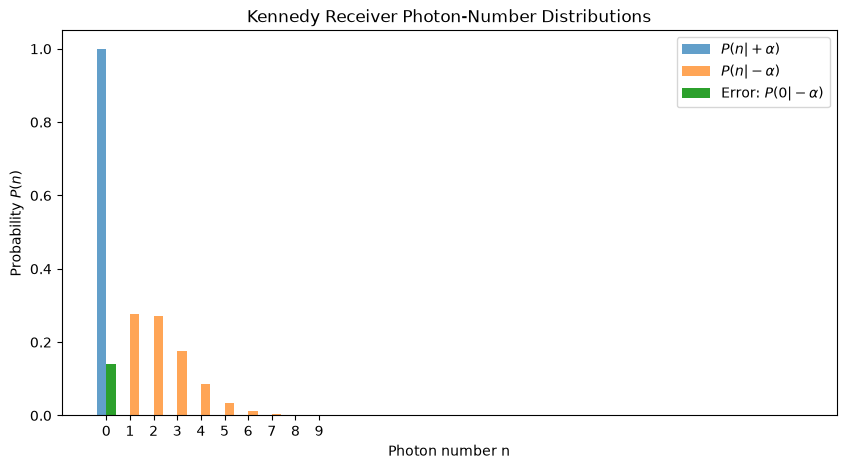

In [ ]:
plt.figure(figsize=(10, 5))

# |+α> distribution
plt.bar(n_values - 0.2, P_plus, width=0.4, alpha=0.7, label=r"$P(n|+\alpha)$")

# |-α> distribution
plt.bar(n_values + 0.2, P_minus, width=0.4, alpha=0.7, label=r"$P(n|-\alpha)$")

# Highlight the important error probability:
# P(n=0 | -α)

plt.bar(0.2, P_minus[0], width=0.4, alpha=1, label=r"Error: $P(0|-\alpha)$")

plt.xlabel("Photon number n")
plt.ylabel(r"Probability $P(n)$")

plt.title("Kennedy Receiver Photon-Number Distributions")
plt.xticks(np.arange(0, 10))
plt.legend()
plt.show()